In [1]:
!pip install xgboost
!pip install termcolor


# Predicción de fumadores — Informe

**Objetivo.** Predecir si una persona es fumadora (`smoking`) a partir de variables clínicas y demográficas.  
El informe incluye: carga de datos, EDA, selección de variables, entrenamiento/evaluación y predicción final.


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier 
from termcolor import colored

In [3]:
dataset=pd.read_excel("../smoking_prediction.xlsx")

In [4]:
dataset.head(5)

,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,3.377083,0.043056,0.041667,0.041667,0.041667,...,0.506250,0.041667,0.004861,0.750000,0.791667,1.125000,Y,0,Y,0
1,1,F,40,160,60,3.375000,0.005556,0.004167,0.041667,0.041667,...,0.504861,0.041667,0.004167,0.916667,0.791667,0.750000,Y,0,Y,0
2,2,M,55,170,60,3.333333,0.005556,0.005556,0.041667,0.041667,...,0.630556,0.041667,0.041667,0.875000,0.666667,0.916667,Y,0,N,1
3,3,M,40,165,70,3.666667,0.045139,0.045139,0.041667,0.041667,...,0.588194,0.041667,0.041667,0.791667,1.083333,0.750000,Y,0,Y,0
4,4,F,40,155,60,3.583333,0.041667,0.041667,0.041667,0.041667,...,0.503472,0.041667,0.004167,0.666667,0.583333,0.916667,Y,0,N,0



## Criterio de EDA y selección de variables (heatmap)

El heatmap de correlación se utiliza sólo para:
- **Eliminar features muertos**: `eyesight(left/right)`, `hearing(left/right)`, `Urine protein`, `dental caries`, `AST`, `ALT`.
- **Eliminar IDs o columnas sin sentido predictivo**: `ID`, `oral`.
- **Evitar *data leakage***: `smoking` se elimina de `X`.

In [5]:
#Eliminamos los potenciales nulos
dataset.isnull().mean()*100

ID                     0.0
gender                 0.0
age                    0.0
height(cm)             0.0
weight(kg)             0.0
waist(cm)              0.0
eyesight(left)         0.0
eyesight(right)        0.0
hearing(left)          0.0
hearing(right)         0.0
systolic               0.0
relaxation             0.0
fasting blood sugar    0.0
Cholesterol            0.0
triglyceride           0.0
HDL                    0.0
LDL                    0.0
hemoglobin             0.0
Urine protein          0.0
serum creatinine       0.0
AST                    0.0
ALT                    0.0
Gtp                    0.0
oral                   0.0
dental caries          0.0
tartar                 0.0
smoking                0.0
dtype: float64

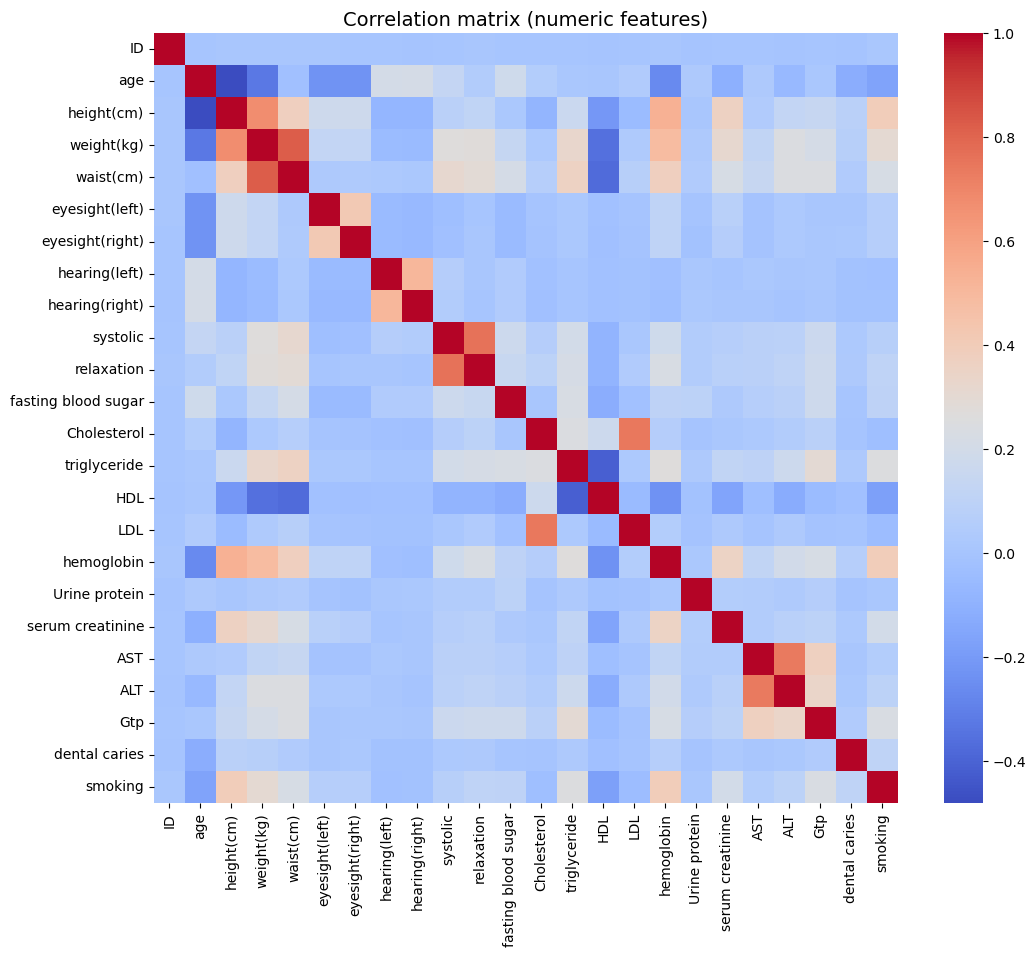

In [6]:
plt.figure(figsize=(12,10))
sns.heatmap(dataset.corr(numeric_only=True), 
            cmap="coolwarm", 
            annot=False)
plt.title("Correlation matrix (numeric features)", fontsize=14)
plt.show()

In [7]:
dataset.smoking.value_counts(normalize=True).mul(100)

smoking
0    63.342
1    36.658
Name: proportion, dtype: float64

In [8]:
cols_to_drop = ['ID', 'oral', 'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)', 'Urine protein', 'dental caries', 'AST', 'ALT', 'smoking']
cols_to_train = ["tartar", "gender"]

In [9]:
X = dataset.drop(columns=cols_to_drop, axis=1).copy()
y = dataset.smoking.copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

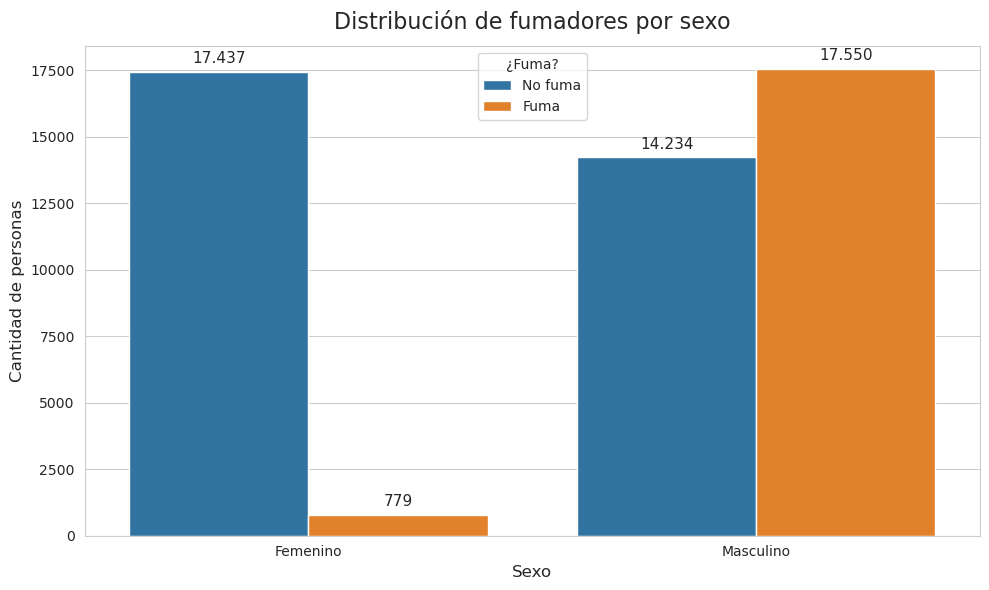

In [10]:

df_plot = dataset.copy()
df_plot['gender'] = df_plot['gender'].replace({'F':'Femenino','M':'Masculino'})
df_plot['smoking'] = df_plot['smoking'].replace({0:'No fuma', 1:'Fuma'})
df_plot = df_plot[df_plot['gender'].isin(['Femenino','Masculino']) & df_plot['smoking'].isin(['No fuma','Fuma'])]

tmp = df_plot.groupby(['gender','smoking']).size().reset_index(name='count')

order_gender = ['Femenino','Masculino']
order_smoke = ['No fuma','Fuma']

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")
ax = sns.barplot(data=tmp, x='gender', y='count', hue='smoking',
                 order=order_gender, hue_order=order_smoke)

ax.set_title('Distribución de fumadores por sexo', fontsize=16, pad=12)
ax.set_xlabel('Sexo', fontsize=12)
ax.set_ylabel('Cantidad de personas', fontsize=12)
ax.legend(title='¿Fuma?', frameon=True)

for p in ax.patches:
    h = float(p.get_height())
    if h > 1e-6:
        ax.annotate(f'{int(round(h)):,}'.replace(',', '.'),
                    (p.get_x() + p.get_width()/2., h),
                    ha='center', va='bottom', fontsize=11,
                    xytext=(0,4), textcoords='offset points')

plt.tight_layout()
plt.show()


In [11]:
X_train.head(5)

,gender,age,height(cm),weight(kg),waist(cm),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,serum creatinine,Gtp,tartar
28042,M,20,175,70,3.128472,5.708333,2.625000,4.166667,7.750000,4.083333,2.916667,4.000000,0.670833,0.006250,1.375000,N
24487,M,30,175,80,3.375000,4.750000,3.000000,3.750000,10.875000,4.083333,2.833333,7.208333,0.670833,0.042361,1.000000,N
23191,M,40,165,75,3.625000,5.041667,3.250000,5.041667,6.666667,4.666667,1.958333,3.791667,0.587500,0.043056,1.541667,Y
12235,F,60,150,50,3.416667,5.625000,3.916667,4.041667,10.500000,5.875000,2.458333,7.750000,0.585417,0.004861,0.958333,Y
36523,F,55,155,55,3.213889,5.375000,3.166667,4.416667,9.041667,3.416667,2.333333,5.916667,0.541667,0.004167,0.875000,N


## Transformación de variables

Se convierten las variables no numéricas a formato numérico utilizando **One-Hot Encoding (OHE)** para que puedan ser procesadas correctamente por los algoritmos de aprendizaje automático.

Las variables categóricas **`tartar`** y **`gender`** se mantienen y se codifican mediante OHE, ya que aportan información útil para predecir si el sujeto es fumador.

In [12]:
ohe = OneHotEncoder(sparse_output=False).fit(X_train[cols_to_train])

In [13]:
encoded = ohe.transform((X_train[cols_to_train]))

In [14]:
encoded_df = pd.DataFrame(columns=ohe.get_feature_names_out(), data = encoded, index=X_train.index)

In [15]:
X_train = pd.concat([X_train, encoded_df], axis="columns")

In [16]:
X_train = X_train.drop(cols_to_train, axis=1)

In [17]:
encoded_test = ohe.transform((X_test[cols_to_train]))

In [18]:
encoded_df_test = pd.DataFrame(columns=ohe.get_feature_names_out(), data = encoded_test, index=X_test.index)

In [19]:
X_test = pd.concat([X_test, encoded_df_test], axis="columns")

In [20]:
X_test = X_test.drop(cols_to_train, axis=1)

In [21]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37500 entries, 28042 to 24022
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  37500 non-null  int64  
 1   height(cm)           37500 non-null  int64  
 2   weight(kg)           37500 non-null  int64  
 3   waist(cm)            37500 non-null  float64
 4   systolic             37500 non-null  float64
 5   relaxation           37500 non-null  float64
 6   fasting blood sugar  37500 non-null  float64
 7   Cholesterol          37500 non-null  float64
 8   triglyceride         37500 non-null  float64
 9   HDL                  37500 non-null  float64
 10  LDL                  37500 non-null  float64
 11  hemoglobin           37500 non-null  float64
 12  serum creatinine     37500 non-null  float64
 13  Gtp                  37500 non-null  float64
 14  tartar_N             37500 non-null  float64
 15  tartar_Y             37500 non-null  

In [22]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12500 entries, 17206 to 49537
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  12500 non-null  int64  
 1   height(cm)           12500 non-null  int64  
 2   weight(kg)           12500 non-null  int64  
 3   waist(cm)            12500 non-null  float64
 4   systolic             12500 non-null  float64
 5   relaxation           12500 non-null  float64
 6   fasting blood sugar  12500 non-null  float64
 7   Cholesterol          12500 non-null  float64
 8   triglyceride         12500 non-null  float64
 9   HDL                  12500 non-null  float64
 10  LDL                  12500 non-null  float64
 11  hemoglobin           12500 non-null  float64
 12  serum creatinine     12500 non-null  float64
 13  Gtp                  12500 non-null  float64
 14  tartar_N             12500 non-null  float64
 15  tartar_Y             12500 non-null  

In [23]:
xgModel = XGBClassifier()  #creo el modelo

In [24]:
xgModel.fit(X_train, y_train) #entreno el modelo

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [25]:
train_pred = xgModel.predict(X_train)
test_pred = xgModel.predict(X_test)

In [26]:
def print_report(title, colour, y_true, y_pred):
    print(colored(f"\n---------------------------------- {title} -----------------------------------------------", colour))
    print(classification_report(y_true, y_pred, digits=3))
    print(colored("\n---------------------------------------------------------------------------------------\n", colour))

print("\n---------------------------------- EVALUACIÓN DEL MODELO ----------------------------------\n")
print_report("TRAIN", "green", y_train, train_pred)
print_report("TEST", "blue", y_test, test_pred)


---------------------------------- EVALUACIÓN DEL MODELO ----------------------------------


---------------------------------- TRAIN -----------------------------------------------
              precision    recall  f1-score   support

           0      0.893     0.870     0.881     23753
           1      0.785     0.819     0.802     13747

    accuracy                          0.852     37500
   macro avg      0.839     0.845     0.842     37500
weighted avg      0.853     0.852     0.852     37500


---------------------------------------------------------------------------------------


---------------------------------- TEST -----------------------------------------------
              precision    recall  f1-score   support

           0      0.820     0.796     0.807      7918
           1      0.664     0.697     0.680      4582

    accuracy                          0.760     12500
   macro avg      0.742     0.746     0.744     12500
weighted avg      0.762     0.760     


## Métricas y validación

Se separa el dataset con `test_size=0.25` y `stratify=y`.  
Resultados típicos obtenidos:
- **Train**: accuracy ≈ 0.852; f1 (fumador) ≈ 0.802  
- **Test**: accuracy ≈ 0.760; f1 (fumador) ≈ 0.680

La diferencia (~9 pts) es **esperable** en boosting sin *tuning* y sugiere **buena generalización** sin *leakage*.



## Conclusiones

- El modelo XGBoost entrega desempeño consistente en test (accuracy ~0.760; f1 fumador ~0.680).  
- El heatmap se usó sólo para remover columnas sin valor aparente, quitar IDs y evitar *leakage*.  
- Variables como `Gtp` se mantienen aunque su correlación lineal sea baja, porque los árboles capturan **umbrales** y **interacciones**.  


In [27]:
results = pd.read_excel("../smoking_prediction_entrega.xlsx")

In [28]:
encoded_ohe_results = ohe.transform(results[["tartar", "gender"]])
encoded_df_results = pd.DataFrame(columns=ohe.get_feature_names_out(), data=encoded_ohe_results, index=results.index)
X_model = results.drop(["ID", "oral", "weight(kg)", "height(cm)", "Urine protein", "dental caries", "hearing(right)", "hearing(left)", "gender", "tartar"], axis=1).copy()

X_results = pd.concat([X_model, encoded_df_results], axis=1)

X_results = X_results.reindex(columns=xgModel.feature_names_in_, fill_value=0)

prediction = xgModel.predict(X_results)

results["smoking"] = prediction

In [29]:
results.head(5)

,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,27358,M,25,160,65,3.420139,0.045139,0.002778,0.041667,0.041667,...,0.631250,0.041667,0.006250,0.750000,0.708333,0.708333,Y,0,Y,0
1,27364,M,30,180,80,3.458333,0.043056,0.006250,0.041667,0.041667,...,0.587500,0.041667,0.041667,0.791667,1.125000,1.333333,Y,0,N,0
2,27368,M,55,165,60,3.416667,0.004861,0.005556,0.041667,0.041667,...,0.625694,0.041667,0.006250,1.083333,1.291667,2.000000,Y,1,Y,1
3,27378,M,20,175,75,3.625000,0.045139,0.045139,0.041667,0.041667,...,0.627083,0.041667,0.043750,0.833333,0.583333,0.458333,Y,0,N,0
4,27381,M,25,165,80,3.791667,0.043056,0.041667,0.041667,0.041667,...,0.670833,0.041667,0.041667,1.250000,1.625000,1.958333,Y,1,Y,0


In [30]:
results.to_excel("dataset_output.xlsx", index=False)